## Importing libraries

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

## Loading dataset

In [33]:
df = pd.read_csv('Telco-Customer-Churn.csv')

## Data understanding

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [35]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Obzirom da je 'TotalCharges' pohranjen kao string podatak, izvršena je konverzija u numerički tip podatka

## Data cleaning

In [37]:
df.drop(columns=['customerID'], inplace=True)

Kolona customerID je uklonjena zbog toga što ne doprinosti cjelokupnoj analizi.

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [40]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})


In [41]:
df['MultipleLines'].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [42]:
df['MultipleLines'] = df['MultipleLines'].map({
     'No phone service': 0,
     'No': 1,
     'Yes': 2,
})

In [43]:
df['InternetService'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [44]:
df['InternetService'] = df['InternetService'].map({
    'DSL': 0, 
    'Fiber optic': 1, 
    'No': 2
})

In [45]:
df['OnlineSecurity'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [46]:
df['OnlineSecurity'] = df['OnlineSecurity'].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [47]:
df['OnlineBackup'].unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [48]:
df['OnlineBackup'] = df['OnlineBackup'].map({
    'Yes': 0, 
    'No': 1, 
    'No internet service': 2
})

In [49]:
df['DeviceProtection'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [50]:
df['DeviceProtection'] = df['DeviceProtection'].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [51]:
df['TechSupport'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [52]:
df['TechSupport'] = df['TechSupport'].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [53]:
df['StreamingTV'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [54]:
df['StreamingTV'] = df['StreamingTV'].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [55]:
df['StreamingMovies'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [56]:
df['StreamingMovies'] = df['StreamingMovies'].map({
    'No': 0, 
    'Yes': 1, 
    'No internet service': 2
})

In [57]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [58]:
df['Contract'] = df['Contract'].map({
    'Month-to-month': 0, 
    'One year': 1, 
    'Two year': 2
})

In [59]:
df['PaymentMethod'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [60]:
df['PaymentMethod'] = df['PaymentMethod'].astype(str).str.strip().map({
    'Electronic check': 0, 
    'Mailed check': 1, 
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})


## Data preparation for models training

In [65]:
x = df.drop(columns=['Churn'])
y = df['Churn']

In [66]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 0)

## Modeling and evaluation

### Decission tree

In [75]:
def gini_index (class1_count, class2_count, total_count):
    return 1 - (class1_count / total_count)**2 - (class2_count / total_count)**2

def weighted_average(weighted_pairs):
    total = 0

    for p in weighted_pairs:
        total += p[0]

    average = 0

    for subset_count, subset_gini in weighted_pairs:
        average = subset_count/total * subset_gini
    return average

In [76]:
weighted_pairs = []

for g in df['gender'].unique():
    df_gender = df[df['gender'] == g]

    churned = df_gender[df_gender['Churn'] == 1]['gender'].count()
    not_churned = df_gender[df_gender['Churn'] == 0]['gender'].count()
    total = churned + not_churned
    gini = gini_index(churned, not_churned, total)

    weighted_pairs.append([total, gini])

    print(f"{churned} {'females' if g == 0 else 'males'} churned, and {not_churned} not churned, of {total} total")
    print(f"Gini impurity index of {'female' if g == 0 else 'male'} subset is {gini}\n")

print(f"Weighted average of gender column is {weighted_average(weighted_pairs)}")

939 males churned, and 2549 not churned, of 3488 total
Gini impurity index of male subset is 0.3934707660866089

930 females churned, and 2625 not churned, of 3555 total
Gini impurity index of female subset is 0.38633409888016534

Weighted average of gender column is 0.19500464596322417


Iz prethodno izvršenog koda je vidljivo da od 3488 žena u cijelom dataset-u, 939 žena je napustilo uslugu dok 2549 žena nije napustilo uslugu.

Iz prethodno izvršenog koda je vidljivo da od 3555 muškaraca u cijelom dataset-u, 930 muškaraca je napustilo uslugu dok 2625 muškaraca nije napustilo uslugu.

## Prediction and evaluation

In [79]:
model = DecisionTreeClassifier(random_state=1)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [80]:
y_pred = model.predict(x_test)
y_pred 

array([0, 0, 1, ..., 0, 0, 1], shape=(1409,))

[[826 215]
 [192 176]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1041
           1       0.45      0.48      0.46       368

    accuracy                           0.71      1409
   macro avg       0.63      0.64      0.63      1409
weighted avg       0.72      0.71      0.71      1409



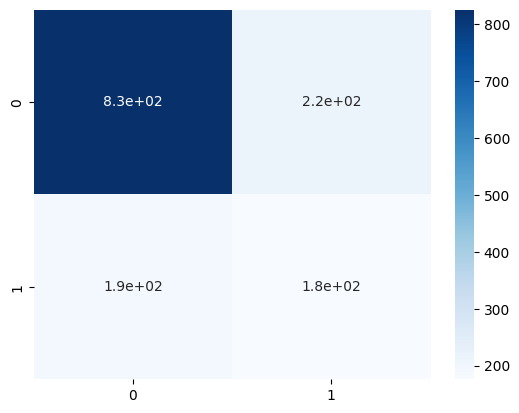

In [81]:
matrix1 = confusion_matrix(y_test, y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap='Blues')
print(classification_report(y_test, y_pred))

## Decision tree algorithm vs Logistic regression and KNN

Logistic Regression

In [85]:
model_lr = LogisticRegression(max_iter=2000) 
model_lr.fit(x_train, y_train)
y_pred_lr = model_lr.predict(x_test)

[[931 110]
 [176 192]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1041
           1       0.64      0.52      0.57       368

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



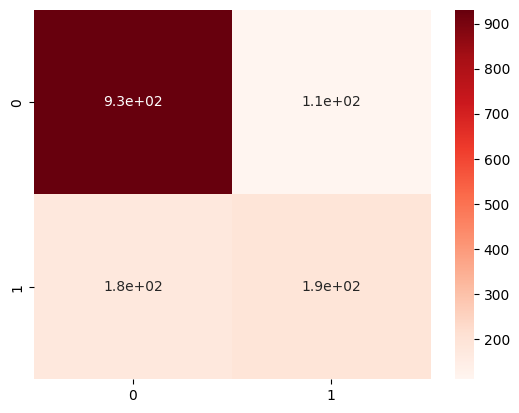

In [86]:
matrix_lr = confusion_matrix(y_test, y_pred_lr)
print(matrix_lr)
ax2 = sns.heatmap(matrix_lr, annot=True, cmap='Reds')
print(classification_report(y_test, y_pred_lr))


KNN

In [87]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train, y_train)
y_pred_knn = model_knn.predict(x_test)

[[890 151]
 [192 176]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1041
           1       0.54      0.48      0.51       368

    accuracy                           0.76      1409
   macro avg       0.68      0.67      0.67      1409
weighted avg       0.75      0.76      0.75      1409



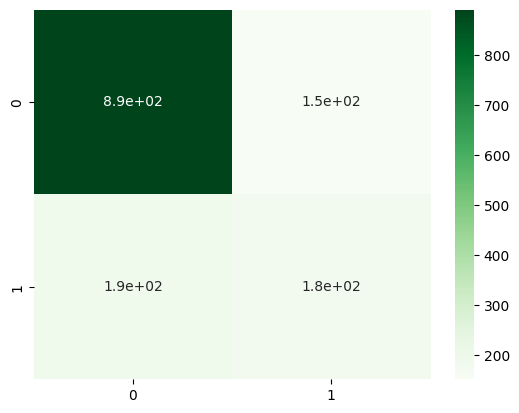

In [88]:
matrix_knn = confusion_matrix(y_test, y_pred_knn)
print(matrix_knn)
ax3 = sns.heatmap(matrix_knn, annot=True, cmap='Greens')
print(classification_report(y_test, y_pred_knn))

## Conclusion

Logistička regresija je pokazala najbolje rezultate u skoro svim ključnim parametrima:

    Najveća ukupna tačnost (Accuracy): 80%, dok kNN ima 76%, a Decision Tree 71%.

    Najbolji Precision za Churn (klasa 1): 0.64. To znači da kada ovaj model predvidi da će korisnik otići, on je u 64% slučajeva u pravu (mnogo precizniji od Decision Tree-a koji je na 0.45).

    Najmanje lažnih uzbuna: Iz matrice zabune vidimo da je ovaj model samo 110 puta pogriješio predviđajući odlazak (False Positive), dok je Decision Tree to uradio čak 215 puta.